In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [5]:
# 1. Load the data
file_path = './data/Dataset_02_LTE_1800.csv'

print(f"Loading {file_path}...")
df_lte = pd.read_csv(file_path)

Loading ./data/Dataset_02_LTE_1800.csv...


In [6]:
# 2. Inspect the raw columns
print("\n--- Dataset Columns ---")
print(df_lte.columns.tolist())

print(f"\nTotal rows loaded: {len(df_lte)}")
print("\n--- First 5 Rows ---")
display(df_lte.head())


--- Dataset Columns ---
['Base station', 'Sector', 'Timestamp', 'Radio unit energy consumption', 'Baseband energy consumption', '4G max active users DL', '4G max active users UL', '4G data volume DL', '4G data volume UL', '4G max RRC users', '4G RB utilization', '4G CQI rank 1', '4G CQI rank 2', '4G CQI rank 3', '4G CQI rank 4', '4G RRC users', '4G active users UL', '4G active users DL', '4G MIMO rank DL']

Total rows loaded: 1800920

--- First 5 Rows ---


,Base station,Sector,Timestamp,Radio unit energy consumption,Baseband energy consumption,4G max active users DL,4G max active users UL,4G data volume DL,4G data volume UL,4G max RRC users,4G RB utilization,4G CQI rank 1,4G CQI rank 2,4G CQI rank 3,4G CQI rank 4,4G RRC users,4G active users UL,4G active users DL,4G MIMO rank DL
0,Site 61,1,2025-02-27 07:30:00,39.0,89.0,1.0,5.0,233.64,10.90,9.0,5.11,12.29,12.56,10.27,9.50,4.42,1.58,1.04,1.92
1,Site 61,2,2025-02-27 07:30:00,34.0,89.0,1.0,2.0,155.37,11.01,10.0,2.90,11.64,13.84,8.83,9.00,4.23,1.38,1.02,1.80
2,Site 61,3,2025-02-27 07:30:00,32.0,89.0,1.0,2.0,23.00,1.98,4.0,1.23,13.20,12.79,13.58,12.52,0.98,1.25,1.02,1.80
3,Site 61,1,2025-02-24 01:15:00,22.0,89.0,0.0,0.0,0.00,0.00,0.0,NaN,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00
4,Site 61,2,2025-02-24 01:15:00,22.0,89.0,0.0,0.0,0.00,0.00,0.0,NaN,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00


In [7]:
# 1. Create a unique Cell ID and parse timestamps
# A single base station has multiple sectors. We need to forecast at the sector level.
df_lte['Cell_ID'] = df_lte['Base station'] + "_Sec_" + df_lte['Sector'].astype(str)
df_lte['Timestamp'] = pd.to_datetime(df_lte['Timestamp'])

# Sort chronologically to ensure our time-series doesn't leak future data into the past
df_lte = df_lte.sort_values(by=['Cell_ID', 'Timestamp'])

In [8]:
# 2. Handle missing values
# NaNs in PM counters usually occur during idle periods. Fill with 0.
df_lte = df_lte.fillna(0)

In [11]:
# 3. Find the most heavily loaded cell to visualize
top_cell = df_lte.groupby('Cell_ID')['4G data volume DL'].sum().idxmax()
print(f"Top traffic cell selected for EDA: {top_cell}")

# 4. Extract data for this specific cell
df_top_cell = df_lte[df_lte['Cell_ID'] == top_cell].set_index('Timestamp')


Top traffic cell selected for EDA: Site 265_Sec_3


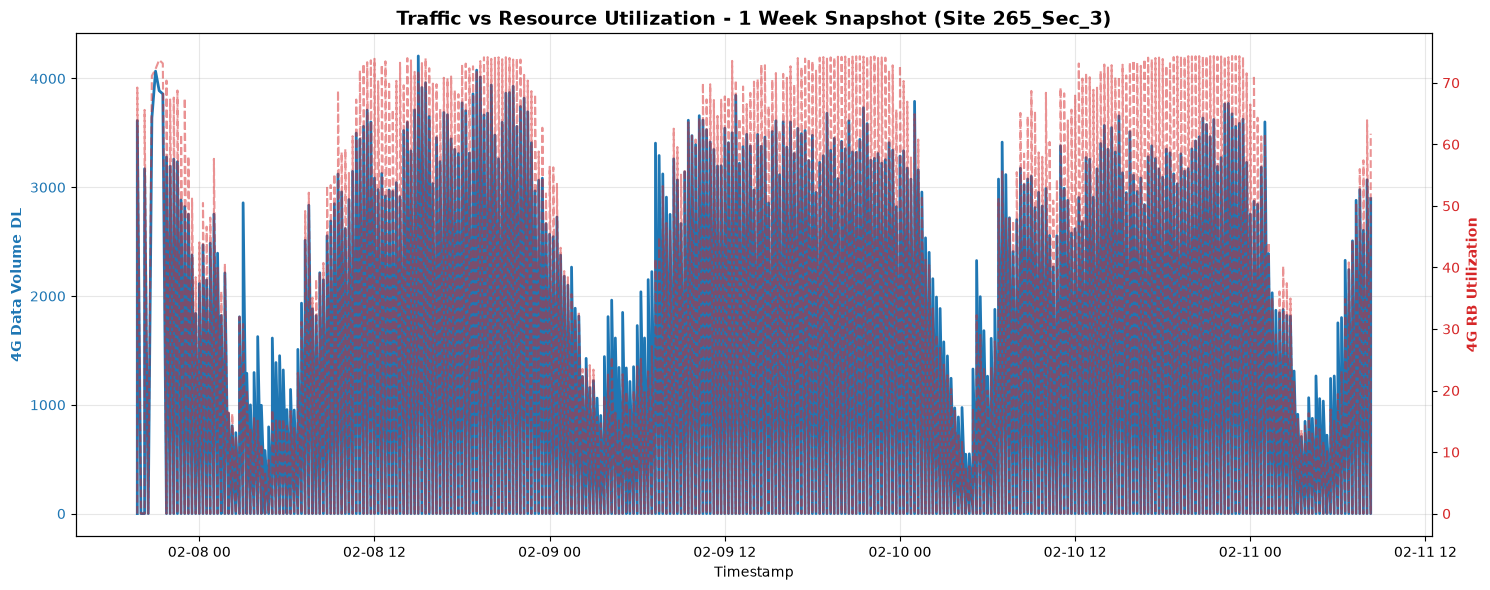

In [12]:
# 5. Plot 1 week of data (7 days * 24 hours * 4 intervals/hr = 672 rows)
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 1: Downlink Data Volume
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('4G Data Volume DL', color=color, fontweight='bold')
ax1.plot(df_top_cell.index[:672], df_top_cell['4G data volume DL'].iloc[:672], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot 2: RB Utilization on a secondary Y-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('4G RB Utilization', color=color, fontweight='bold')  
ax2.plot(df_top_cell.index[:672], df_top_cell['4G RB utilization'].iloc[:672], color=color, alpha=0.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"Traffic vs Resource Utilization - 1 Week Snapshot ({top_cell})", fontsize=14, fontweight='bold')
fig.tight_layout()  
plt.show()